In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ast

In [2]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary.csv'

df = pd.read_csv(file_path)

In [3]:
df.shape

(2598, 10)

In [4]:
# 2. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle.csv'

ex = pd.read_csv(file_path)

In [5]:
ex.shape

(605033, 16)

# Generate Exercise Dataset (and the dupe dataset)

## Remove negative rep programs

In [287]:
neg_reps = ex[ex.reps < 0].title.unique()

In [288]:
ex.drop(ex[ex.title.isin(neg_reps)].index, inplace = True)

In [289]:
ex.shape

(261897, 16)

## Find and separate different workout programs with the same titles (different descriptions)

In [290]:
titles = ex.title.unique()

In [291]:
len(ex.title.unique())

1351

In [292]:
diff_desc= []
for title in titles:
    tmp = ex[ex.title == title]
    if len(tmp) != len(tmp[tmp.description == tmp.description.values[0]]) and sum(tmp.description.notna())!= 0:
        diff_desc.append(title)

In [293]:
len(diff_desc)

9

In [294]:
adj_df = pd.DataFrame()
for title in diff_desc:
    desc_list = ex[(ex.title == title)].description.unique()
    tmp_title = 0
    for desc in desc_list:
        tmp = ex[(ex.title == title) & (ex.description == desc)]
        tmp.title = f'{tmp.title.values[0]} ({tmp_title})'
        adj_df = pd.concat([adj_df, tmp], ignore_index=True)
        tmp_title += 1

C:\Users\iamph\AppData\Local\Temp\ipykernel_23036\3548535338.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp.title = f'{tmp.title.values[0]} ({tmp_title})'


In [295]:
adj_df.title.unique()

array(['Torso Limbs (0)', 'Torso Limbs (1)',
       'The Bodybuilding Transformation System (0)',
       'The Bodybuilding Transformation System (1)', 'Greek God (0)',
       'Greek God (1)', 'Alpha Destiny Novice Program (0)',
       'Alpha Destiny Novice Program (1)', 'Superman (0)', 'Superman (1)',
       'Push Pull Legs (0)', 'Push Pull Legs (1)', 'Black Swordsman (0)',
       'Black Swordsman (1)', 'PPL x Arnold (0)', 'PPL x Arnold (1)',
       '3 Day Baki Grappler Condensed Conjugate (0)',
       '3 Day Baki Grappler Condensed Conjugate (1)',
       '3 Day Baki Grappler Condensed Conjugate (2)'], dtype=object)

In [296]:
diff_equip = []
for title in adj_df.title.unique():
    tmp = adj_df[adj_df.title == title]
    if len(tmp) != len(tmp[tmp.equipment == tmp.equipment.values[0]]):
        diff_equip.append(title)

In [297]:
diff_equip

[]

In [298]:
len(adj_df)

3671

## Clean the exercise datasheet (remove the exercise programs with the same title, diff desc, and replace with new title, diff desc)

In [299]:
ex.shape

(261897, 16)

In [300]:
ex.drop(ex[ex.title.isin(diff_desc)].index,inplace=True)

In [301]:
ex = pd.concat([ex,adj_df])

## Adjust Difficulty (make sure each program has the same difficulty)

In [303]:
def set_mapping(s):
    if s == set(['Intermediate','Beginner']):
        s = set(['Intermediate', 'Novice', 'Beginner'])
    elif s == set(['Beginner', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Beginner', 'Intermediate', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Novice', 'Advanced']):
        s = set(['Novice', 'Intermediate', 'Advanced'])
    return s 

ex['level'] = ex['level'].apply(ast.literal_eval)
ex.level = ex.level.apply(set)
ex.level = ex.level.apply(set_mapping)

In [306]:
ex.level.value_counts()

level
{Intermediate}                                62998
{Advanced, Intermediate}                      40150
{Intermediate, Novice}                        37730
{Advanced, Intermediate, Beginner, Novice}    23122
{Novice}                                      21975
{Intermediate, Beginner, Novice}              19405
{Beginner}                                    15263
{Beginner, Novice}                            15150
{Advanced, Intermediate, Novice}              14722
{Advanced}                                    10124
{}                                             1258
Name: count, dtype: int64

In [307]:
ex.shape

(261897, 16)

In [226]:
# df['level'] = df['level'].apply(ast.literal_eval)
# df.level = df.level.apply(set)
# df.level = df.level.apply(set_mapping)

ValueError: malformed node or string: {'Intermediate'}

## Clean up the goals in exercise

In [308]:
ex['goal'] = ex['goal'].apply(ast.literal_eval)

In [310]:
ex.goal = ex.goal.apply(set)

In [312]:
ex.goal.value_counts()

goal
{Bodybuilding}                                                                                                60625
{Bodybuilding, Muscle & Sculpting}                                                                            34190
{Powerbuilding}                                                                                               16988
{Bodybuilding, Powerbuilding}                                                                                 16902
{Bodybuilding, Powerlifting, Powerbuilding}                                                                   12931
                                                                                                              ...  
{Olympic Weightlifting, Bodyweight Fitness, Athletics}                                                           84
{Bodybuilding, Powerbuilding, Bodyweight Fitness, Athletics}                                                     60
{Powerlifting, Olympic Weightlifting}                              

In [314]:
ex.to_csv(DATA_DIR /'programs_detailed_boostcamp_kaggle_CLEAN.csv')

## Clean up difficulty and goals so each program is consistent

In [315]:
titles = ex.title.unique()

In [322]:
tmp = ex2[ex2.title == 'nSuns_Rebuild by KSI']
idx = tmp.index

In [323]:
tmp

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
837,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,{Beginner},{Bodybuilding},Full Gym,7.0,90.0,1.0,1.0,4.0,Squat (Barbell),1.0,15.0,8.0,2025-04-06 03:06:00,2025-06-18 08:29:00
838,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,{Beginner},{Bodybuilding},Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Press (45 Degrees),1.0,100.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
839,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,{Beginner},{Bodybuilding},Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Extension,4.0,5.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
840,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,{Beginner},{Bodybuilding},Full Gym,7.0,90.0,1.0,1.0,4.0,Preacher Curl (Barbell),1.0,10.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
841,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,{Beginner},{Bodybuilding},Full Gym,7.0,90.0,1.0,2.0,4.0,Bent Over Row (Barbell),1.0,15.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
972,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,7.0,4.0,4.0,V-Handle Tricep Pushdown (Cable),1.0,14.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
973,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,7.0,5.0,4.0,Overhead Press (Barbell),1.0,10.0,7.0,2025-04-06 03:06:00,2025-06-18 08:29:00
974,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,7.0,5.0,4.0,Bench Press (Barbell),1.0,12.0,7.0,2025-04-06 03:06:00,2025-06-18 08:29:00
975,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,7.0,5.0,4.0,Pull-Up (Bodyweight),4.0,10.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00


In [335]:
list(titles)[:2]

['nSuns_Rebuild by KSI', 'Rampage']

In [337]:
ex2 = ex.copy(deep = True)
new_ex = pd.DataFrame()
for title in list(titles):
    
    tmp = ex2[ex2.title == title]
    idx = tmp.index
    
    clean_values = tmp.level.dropna().values
    result_set = str(set([]).union(*clean_values))
    
    tmp['level'] = result_set

    clean_values = tmp.goal.dropna().values
    result_set = str(set([]).union(*clean_values))
    
    tmp['goal'] = result_set
    new_ex = pd.concat([new_ex,tmp])

C:\Users\iamph\AppData\Local\Temp\ipykernel_23036\1252305087.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['level'] = result_set
C:\Users\iamph\AppData\Local\Temp\ipykernel_23036\1252305087.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['goal'] = result_set


In [338]:
new_ex

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
837,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Beginner', 'Advanced', 'Intermediate'}","{'Bodybuilding', 'Powerbuilding'}",Full Gym,7.0,90.0,1.0,1.0,4.0,Squat (Barbell),1.0,15.0,8.0,2025-04-06 03:06:00,2025-06-18 08:29:00
838,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Beginner', 'Advanced', 'Intermediate'}","{'Bodybuilding', 'Powerbuilding'}",Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Press (45 Degrees),1.0,100.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
839,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Beginner', 'Advanced', 'Intermediate'}","{'Bodybuilding', 'Powerbuilding'}",Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Extension,4.0,5.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
840,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Beginner', 'Advanced', 'Intermediate'}","{'Bodybuilding', 'Powerbuilding'}",Full Gym,7.0,90.0,1.0,1.0,4.0,Preacher Curl (Barbell),1.0,10.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
841,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Beginner', 'Advanced', 'Intermediate'}","{'Bodybuilding', 'Powerbuilding'}",Full Gym,7.0,90.0,1.0,2.0,4.0,Bent Over Row (Barbell),1.0,15.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666,3 Day Baki Grappler Condensed Conjugate (2),This program is designed for martial artists w...,"{'Advanced', 'Intermediate'}","{'Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,4.0,3.0,5.0,Overhead Press (Barbell),3.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3667,3 Day Baki Grappler Condensed Conjugate (2),This program is designed for martial artists w...,"{'Advanced', 'Intermediate'}","{'Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,4.0,3.0,5.0,Barbell Row,3.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3668,3 Day Baki Grappler Condensed Conjugate (2),This program is designed for martial artists w...,"{'Advanced', 'Intermediate'}","{'Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,4.0,3.0,5.0,Zercher Squat (Barbell),6.0,10.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3669,3 Day Baki Grappler Condensed Conjugate (2),This program is designed for martial artists w...,"{'Advanced', 'Intermediate'}","{'Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,4.0,3.0,5.0,Upright Row (Barbell),4.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00


In [340]:
new_ex.to_csv(DATA_DIR / 'programs_detailed_boostcamp_kaggle_CLEAN2.csv', index = False)

# Analyse programs by shape of program (look at programs that are much bigger than their intended exercise length)

In [208]:
ex.title.unique().shape

(1361,)

## Expected number of exercises
For the last week, observe the number of exercises and multiply that by the number of weeks. 

Compare the output to the total number of exercises provided

In [209]:
titles = ex.title.unique()

In [210]:
len(titles)

1361

In [143]:
df2 = pd.DataFrame()
idx = 0
for title in titles:
    df2.loc[idx, 'title'] = title 
    
    tmp = ex[ex.title == title]
    df2.loc[idx, 'true_length'] = len(tmp)
    
    last_week = tmp.week.max()
    tmp2 = tmp[tmp.week == last_week]

    df2.loc[idx, 'final_week_length'] = len(tmp2)
    df2.loc[idx, 'expected_length'] = len(tmp2) * last_week
    df2.loc[idx, 'num_weeks'] = last_week
    
    df2.loc[idx, 'length_ratio'] = df2.loc[idx, 'true_length']/df2.loc[idx, 'expected_length']
    if df2.loc[idx, 'length_ratio'] >= 1.2: #Let's analyse the programs that likely have their final week as one of the shorter weeks
        max_length = len(tmp2)
        max_length_week = last_week
        for i in range(int(last_week)):
            tmp2 = tmp[tmp.week == i]
            if len(tmp2) > max_length:
                max_length = len(tmp2)
                max_length_week = i
                
        df2.loc[idx, 'longest_week'] = max_length_week
        df2.loc[idx, 'longest_week_length'] = max_length
        df2.loc[idx, 'adj_expected_length'] = max_length * last_week
        df2.loc[idx, 'adj_length_ratio'] = df2.loc[idx, 'true_length']/df2.loc[idx, 'adj_expected_length']
    idx += 1

In [144]:
df2.to_csv(DATA_DIR / 'program_lengths.csv', index= False)

In [145]:
df2.sort_values('length_ratio', ascending=False)

,title,true_length,final_week_length,expected_length,num_weeks,length_ratio,longest_week,longest_week_length,adj_expected_length,adj_length_ratio
239,PPL X Upper/Lower (1),141.0,1.0,5.0,5.0,28.200000,1.0,35.0,175.0,0.805714
460,Bogg 'DUP' SBD,136.0,1.0,6.0,6.0,22.666667,2.0,33.0,198.0,0.686869
1188,Maharlika,127.0,1.0,6.0,6.0,21.166667,2.0,34.0,204.0,0.622549
48,Kratos | Physique and Strength of the God of War,379.0,3.0,39.0,13.0,9.717949,5.0,34.0,442.0,0.857466
970,Challenging (1),135.0,3.0,15.0,5.0,9.000000,1.0,33.0,165.0,0.818182
...,...,...,...,...,...,...,...,...,...,...
1165,Body,13.0,4.0,16.0,4.0,0.812500,NaN,NaN,NaN,NaN
362,Back to the basics,105.0,15.0,135.0,9.0,0.777778,NaN,NaN,NaN,NaN
808,Wendler 5/3/1 God is a Beast- leader,28.0,6.0,36.0,6.0,0.777778,NaN,NaN,NaN,NaN
210,PPL+1: Precision Progression,242.0,26.0,338.0,13.0,0.715976,NaN,NaN,NaN,NaN


Good thing here is that all the programs are encapsulated within themselves. We can appropriately analyse each of these programs as is

## Analyse Number of exercises by week

In [211]:
df3 = pd.DataFrame()
idx = 0
for title in titles:
    tmp = ex[ex.title == title]
    
    df3.loc[idx, 'title'] = title

    if sum(tmp.description.notna())!= 0:
        df3.loc[idx, 'description'] = ex[ex.title == title].description.values[0]
    else:
        df3.loc[idx, 'description'] = 'N/A'
    
    clean_values = tmp.level.dropna().values
    result_set = set([]).union(*clean_values)
    
    df3.loc[idx, 'level'] = str(result_set)

    clean_values = tmp.goal.dropna().values
    result_set = set([]).union(*clean_values)
    
    df3.loc[idx, 'goal'] = str(result_set)
    
    df3.loc[idx, 'equipment'] = ex[ex.title == title].equipment.values[0]
    df3.loc[idx, 'program_length_weeks'] = int(tmp.week.max())
    df3.loc[idx, 'time_per_workout'] = ex[ex.title == title].time_per_workout.values[0]
    df3.loc[idx, 'total_exercises'] = len(tmp)

    days = 0
    for week in range(1,int(tmp.week.max())+1):
        days += int(tmp[tmp.week == week].day.max())
    df3.loc[idx, 'program_length_days'] = days

    intensities = []
    for week in range(1,int(tmp.week.max())+1):
            tmp2 = tmp[(tmp.week == week)]
            max_days = int(tmp2.day.max()) # Number of days in that week
            for day in range(1,max_days + 1):
                intensities.append(tmp[(tmp.week == week) & (tmp.day == day)].intensity.mean())
    df3.loc[idx, 'average_intensity'] = np.mean(intensities).round(2)
    idx += 1

In [212]:
df3.to_csv(DATA_DIR / 'program_summary_CLEAN.csv')

In [160]:
df[df.title == title]

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit


In [157]:
df[df.title == title]

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit


In [33]:
df3

,title,description,level,equipment,program_length_weeks,total_exercises,program_length_days,average_intensity
0,Matt Vena modified,"Modofied version of Matt Vena program, with eq...","{'Advanced', 'Novice', 'Beginner', 'Intermedia...",Full Gym,4.0,92.0,13.0,9.91


In [23]:
tmp = ex[ex.title == title]

In [25]:
len(tmp)

92

### Calculate the average intensity

In [41]:
tmp[(tmp.week == 1) & (tmp.day == 1)].intensity.mean()

np.float64(8.857142857142858)

In [47]:
len(intensities)

13

In [52]:
np.mean(intensities).round(2)

np.float64(9.91)

### Calculate total level

In [54]:
tmp.level.value_counts()

level
{Intermediate}                                52
{Advanced, Intermediate, Beginner, Novice}    40
Name: count, dtype: int64

In [60]:
tmp.level.value_counts()

level
{Intermediate}                                52
{Advanced, Intermediate, Beginner, Novice}    40
Name: count, dtype: int64

### Check if the equipment changes

In [36]:
len(titles)

1351

In [37]:
len(tmp)

92

In [44]:
diff_equip = []
for title in titles:
    tmp = ex[ex.title == title]
    if len(tmp) != len(tmp[tmp.equipment == tmp.equipment.values[0]]):
        diff_equip.append(title)

In [45]:
diff_equip

['Superman', 'Push Pull Legs', 'Black Swordsman']

In [47]:
ex[ex.title == 'Superman'].equipment.value_counts()

equipment
Garage Gym       192
Dumbbell Only     60
Name: count, dtype: int64

In [52]:
ex[ex.title == 'Superman'] # Likely to be two different programs

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
152567,Superman,Bodybuilding to look like Superman,{Intermediate},"['Bodybuilding', 'Muscle & Sculpting']",Garage Gym,12.0,60.0,1.0,1.0,4.0,Incline Bench Press (Barbell),3.0,12.0,9.0,2024-05-29 03:08:00,2025-06-18 10:28:00
152568,Superman,Bodybuilding to look like Superman,{Intermediate},"['Bodybuilding', 'Muscle & Sculpting']",Garage Gym,12.0,60.0,1.0,1.0,4.0,Chest Fly (Dumbbell),3.0,12.0,9.0,2024-05-29 03:08:00,2025-06-18 10:28:00
152569,Superman,Bodybuilding to look like Superman,{Intermediate},"['Bodybuilding', 'Muscle & Sculpting']",Garage Gym,12.0,60.0,1.0,1.0,4.0,Lu Raise,3.0,12.0,9.0,2024-05-29 03:08:00,2025-06-18 10:28:00
152570,Superman,Bodybuilding to look like Superman,{Intermediate},"['Bodybuilding', 'Muscle & Sculpting']",Garage Gym,12.0,60.0,1.0,1.0,4.0,T Bar Rows,3.0,12.0,9.0,2024-05-29 03:08:00,2025-06-18 10:28:00
152571,Superman,Bodybuilding to look like Superman,{Intermediate},"['Bodybuilding', 'Muscle & Sculpting']",Garage Gym,12.0,60.0,1.0,2.0,4.0,High Bar Squat (Barbell),3.0,12.0,9.0,2024-05-29 03:08:00,2025-06-18 10:28:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169254,Superman,"Strength, endurance","{Advanced, Intermediate, Beginner, Novice}",['Bodybuilding'],Dumbbell Only,6.0,30.0,6.0,3.0,3.0,Kettlebell Swing,2.0,15.0,6.0,2024-02-13 06:22:00,2025-06-18 08:16:00
169255,Superman,"Strength, endurance","{Advanced, Intermediate, Beginner, Novice}",['Bodybuilding'],Dumbbell Only,6.0,30.0,6.0,3.0,3.0,Kettlebell Clean & Press,3.0,15.0,6.0,2024-02-13 06:22:00,2025-06-18 08:16:00
169256,Superman,"Strength, endurance","{Advanced, Intermediate, Beginner, Novice}",['Bodybuilding'],Dumbbell Only,6.0,30.0,6.0,3.0,3.0,Kettlebell Press,2.0,15.0,7.0,2024-02-13 06:22:00,2025-06-18 08:16:00
169257,Superman,"Strength, endurance","{Advanced, Intermediate, Beginner, Novice}",['Bodybuilding'],Dumbbell Only,6.0,30.0,6.0,4.0,2.0,Kettlebell Swing,1.0,12.0,6.0,2024-02-13 06:22:00,2025-06-18 08:16:00


In [48]:
ex[ex.title == 'Push Pull Legs'].equipment.value_counts()

equipment
Garage Gym    144
Full Gym      126
Name: count, dtype: int64

In [50]:
ex[ex.title == 'Push Pull Legs'] # This is likely two different programs

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
153492,Push Pull Legs,This 3 day a week PPL is for the man or women ...,"{Advanced, Intermediate}","['Powerbuilding', 'Powerlifting']",Garage Gym,8.0,60.0,1.0,1.0,7.0,Incline Bench Press (Barbell),2.0,8.0,8.0,2024-10-15 10:10:00,2025-06-18 10:28:00
153493,Push Pull Legs,This 3 day a week PPL is for the man or women ...,"{Advanced, Intermediate}","['Powerbuilding', 'Powerlifting']",Garage Gym,8.0,60.0,1.0,1.0,7.0,Incline Bench Press (Dumbbell),2.0,12.0,8.0,2024-10-15 10:10:00,2025-06-18 10:28:00
153494,Push Pull Legs,This 3 day a week PPL is for the man or women ...,"{Advanced, Intermediate}","['Powerbuilding', 'Powerlifting']",Garage Gym,8.0,60.0,1.0,1.0,7.0,Cable Crossover,2.0,12.0,8.0,2024-10-15 10:10:00,2025-06-18 10:28:00
153495,Push Pull Legs,This 3 day a week PPL is for the man or women ...,"{Advanced, Intermediate}","['Powerbuilding', 'Powerlifting']",Garage Gym,8.0,60.0,1.0,1.0,7.0,Seated Barbell Shoulder Press,2.0,15.0,8.0,2024-10-15 10:10:00,2025-06-18 10:28:00
153496,Push Pull Legs,This 3 day a week PPL is for the man or women ...,"{Advanced, Intermediate}","['Powerbuilding', 'Powerlifting']",Garage Gym,8.0,60.0,1.0,1.0,7.0,One Arm Lateral Raise (Cable),2.0,9.0,10.0,2024-10-15 10:10:00,2025-06-18 10:28:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401186,Push Pull Legs,Aesthetic,"{Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Bodyweight ...",Full Gym,6.0,60.0,6.0,3.0,7.0,Single Arm Row (Cable),2.0,8.0,8.0,2024-09-18 01:03:00,2025-06-18 11:38:00
401187,Push Pull Legs,Aesthetic,"{Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Bodyweight ...",Full Gym,6.0,60.0,6.0,3.0,7.0,Rear Delt Fly (Cable),1.0,10.0,8.0,2024-09-18 01:03:00,2025-06-18 11:38:00
401188,Push Pull Legs,Aesthetic,"{Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Bodyweight ...",Full Gym,6.0,60.0,6.0,3.0,7.0,Face Pull,2.0,10.0,6.0,2024-09-18 01:03:00,2025-06-18 11:38:00
401189,Push Pull Legs,Aesthetic,"{Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Bodyweight ...",Full Gym,6.0,60.0,6.0,3.0,7.0,Bicep Curl (Cable),3.0,12.0,6.0,2024-09-18 01:03:00,2025-06-18 11:38:00


In [49]:
ex[ex.title == 'Black Swordsman'].equipment.value_counts()

equipment
Full Gym      251
Garage Gym    124
Name: count, dtype: int64

In [51]:
ex[ex.title == 'Black Swordsman'] # Also likely two different programs

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
260773,Black Swordsman,I want this program to have a mixture of calis...,"{Advanced, Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Garage Gym,4.0,30.0,1.0,1.0,5.0,Incline Bench Press (Dumbbell),3.0,10.0,6.0,2025-06-11 11:32:00,2025-06-28 10:58:00
260774,Black Swordsman,I want this program to have a mixture of calis...,"{Advanced, Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Garage Gym,4.0,30.0,1.0,1.0,5.0,Skull Crusher (Dumbbell),3.0,10.0,6.0,2025-06-11 11:32:00,2025-06-28 10:58:00
260775,Black Swordsman,I want this program to have a mixture of calis...,"{Advanced, Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Garage Gym,4.0,30.0,1.0,1.0,5.0,Bench Press (Dumbbell),3.0,10.0,6.0,2025-06-11 11:32:00,2025-06-28 10:58:00
260776,Black Swordsman,I want this program to have a mixture of calis...,"{Advanced, Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Garage Gym,4.0,30.0,1.0,1.0,5.0,French Press,4.0,10.0,6.0,2025-06-11 11:32:00,2025-06-28 10:58:00
260777,Black Swordsman,I want this program to have a mixture of calis...,"{Advanced, Intermediate, Novice}","['Bodybuilding', 'Powerbuilding', 'Muscle & Sc...",Garage Gym,4.0,30.0,1.0,1.0,5.0,Seated Shoulder Press (Dumbbell),3.0,5.0,6.0,2025-06-11 11:32:00,2025-06-28 10:58:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555665,Black Swordsman,A 4 days per week gentleman split designed aro...,{Intermediate},['Powerbuilding'],Full Gym,12.0,90.0,12.0,4.0,5.0,Romanian Deadlift (Barbell),3.0,7.0,5.0,2025-03-27 01:53:00,2025-06-18 09:24:00
555666,Black Swordsman,A 4 days per week gentleman split designed aro...,{Intermediate},['Powerbuilding'],Full Gym,12.0,90.0,12.0,4.0,5.0,Chin-Up (Weighted),3.0,14.0,6.0,2025-03-27 01:53:00,2025-06-18 09:24:00
555667,Black Swordsman,A 4 days per week gentleman split designed aro...,{Intermediate},['Powerbuilding'],Full Gym,12.0,90.0,12.0,4.0,5.0,Single Leg Press,3.0,12.0,5.0,2025-03-27 01:53:00,2025-06-18 09:24:00
555668,Black Swordsman,A 4 days per week gentleman split designed aro...,{Intermediate},['Powerbuilding'],Full Gym,12.0,90.0,12.0,4.0,5.0,Lateral Raise (Dumbbell),3.0,4.0,6.0,2025-03-27 01:53:00,2025-06-18 09:24:00


## Time per workout analysis

In [149]:
titles = ex.title.unique()

In [150]:
len(titles)

1361

In [151]:
tmp

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
3627,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,1.0,5.0,Push Press (Barbell),3.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3628,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,1.0,5.0,Bent Over Row (Barbell),3.0,2.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3629,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,1.0,5.0,Speed Deadlift,6.0,2.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3630,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,1.0,5.0,Preacher Curl (EZ Bar),4.0,2.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3631,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,1.0,5.0,Lat Pulldown,7.0,2.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3632,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,2.0,5.0,Sandbag Box Squat,3.0,6.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3633,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,2.0,5.0,Floor Press (Barbell),8.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3634,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,2.0,5.0,Landmine Twist,3.0,12.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3635,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,2.0,5.0,Sandbag Bent-Over Row,5.0,1.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00
3636,3 Day Baki Grappler Condensed Conjugate 2,This program is designed for martial artists w...,"{Advanced, Intermediate}","['Bodybuilding', 'Muscle & Sculpting', 'Athlet...",Garage Gym,4.0,60.0,1.0,2.0,5.0,Kettlebell Halo,7.0,12.0,9.0,2025-06-21 03:42:00,2025-06-30 01:20:00


In [152]:
diff_workout_times = []
for title in titles:
    tmp = ex[ex.title == title]
    if tmp.time_per_workout.values[0] != np.mean(tmp.time_per_workout):
        diff_workout_times.append(title)

In [153]:
diff_workout_times

[]

All programs have the same workout time!

# Appendix

## Bar plot example

In [107]:
len(ex.title.unique())

1567

<Axes: xlabel='intensity'>

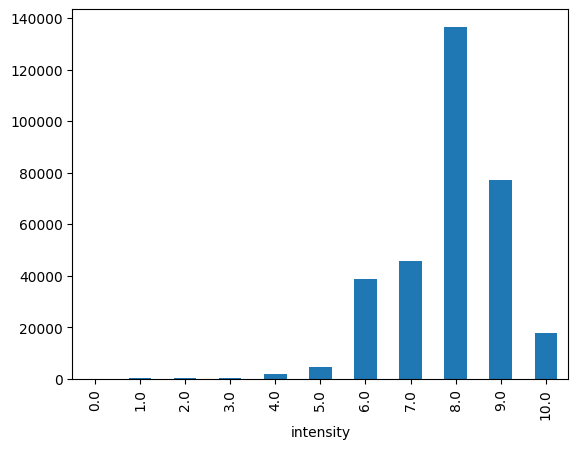

In [95]:
ex.intensity.value_counts().sort_index().plot(kind='bar')

<Axes: >

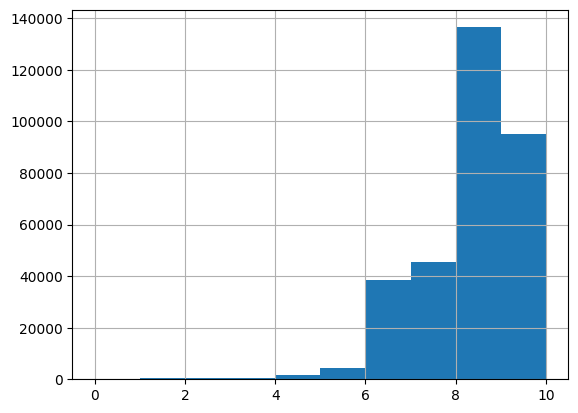

In [89]:
ex.intensity.hist(bins = 10)

# Fix up level and goals

In [3]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary_CLEAN.csv'

df = pd.read_csv(file_path)

# 3. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle_CLEAN2.csv'

ex = pd.read_csv(file_path)

In [8]:
df['level'] = df['level'].apply(ast.literal_eval)
ex['level'] = ex['level'].apply(ast.literal_eval)

In [9]:
df['goal'] = df['goal'].apply(ast.literal_eval)
ex['goal'] = ex['goal'].apply(ast.literal_eval)

## Remove empty sets

### Levels

In [10]:
df.shape

(1361, 10)

In [11]:
df.drop(df[df.level == set()].index, inplace = True)

In [12]:
df.shape

(1360, 10)

In [13]:
ex.shape

(261897, 16)

In [14]:
ex.drop(ex[ex.level == set()].index, inplace = True)

In [15]:
ex.shape

(261689, 16)

### Goals

In [16]:
df.shape

(1360, 10)

In [17]:
df.drop(df[df.goal == set()].index, inplace = True)

In [18]:
df.shape

(1360, 10)

In [19]:
ex.shape

(261689, 16)

In [20]:
ex.drop(ex[ex.goal == set()].index, inplace = True)

In [21]:
ex.shape

(261689, 16)

## Combine level gaps

In [34]:
def set_mapping(s):
    if s == set(['Intermediate','Beginner']):
        s = set(['Intermediate', 'Novice', 'Beginner'])
    elif s == set(['Beginner', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Beginner', 'Intermediate', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Novice', 'Advanced']):
        s = set(['Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Advanced', 'Beginner', 'Novice']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    return s 

In [35]:
df.level = df.level.apply(set_mapping)

In [36]:
ex.level = ex.level.apply(set_mapping)

In [37]:
df.level.value_counts()

level
{Advanced, Intermediate, Beginner, Novice}    310
{Intermediate, Beginner, Novice}              204
{Intermediate, Novice}                        193
{Advanced, Intermediate}                      173
{Advanced, Intermediate, Novice}              158
{Intermediate}                                158
{Beginner, Novice}                             56
{Novice}                                       46
{Beginner}                                     31
{Advanced}                                     31
Name: count, dtype: int64

In [38]:
df.to_csv(DATA_DIR / 'program_summary_CLEAN_260728.csv')
ex.to_csv(DATA_DIR / 'programs_detailed_boostcamp_kaggle_CLEAN_260728.csv')